# ❤️ Heart Disease Prediction
Predicting the presence of heart disease from clinical features (age, cholesterol, blood pressure, chest pain type, etc.) using classic ML classifiers.

This notebook follows the same workflow as the Titanic survival predictor: EDA → cleaning → feature engineering → encoding/scaling → model comparison → hyperparameter tuning → final evaluation.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Model evaluation & validation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

sns.set_style("whitegrid")
print("Libraries successfully imported!")

Libraries successfully imported!


## 1. Load the Data

In [6]:
import pandas as pd
import os

# Local environment paths
train_path = 'data/train.csv'
test_path = 'data/test.csv'

if not os.path.exists(train_path) or not os.path.exists(test_path):
    raise FileNotFoundError(
        f"Could not find data files.\nChecked: {train_path}, {test_path}\n"
        f"Make sure train.csv and test.csv are placed inside a 'data/' folder "
        f"in your project directory."
    )

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
print(f"Loaded train shape: {train.shape}")
print(f"Loaded test shape: {test.shape}")

FileNotFoundError: Could not find data files.
Checked: data/train.csv, data/test.csv
Make sure train.csv and test.csv are placed inside a 'data/' folder in your project directory.

## 2. Data Overview

In [ ]:
# Print data overview and head
print("--- Train Info ---")
train.info()
print("\n--- Missing Values in Train ---")
print(train.isnull().sum())
print("\n--- Missing Values in Test ---")
print(test.isnull().sum())

train.head()

--- Train Info ---
<class 'pandas.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       734 non-null    int64  
 1   sex       734 non-null    int64  
 2   cp        734 non-null    int64  
 3   trestbps  734 non-null    int64  
 4   chol      734 non-null    int64  
 5   fbs       734 non-null    int64  
 6   restecg   734 non-null    int64  
 7   thalach   734 non-null    int64  
 8   exang     734 non-null    int64  
 9   oldpeak   734 non-null    float64
 10  slope     734 non-null    int64  
 11  ca        691 non-null    float64
 12  thal      705 non-null    float64
 13  target    734 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 80.4 KB

--- Missing Values in Train ---
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca          4

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,56,0,2,140,237,0,0,142,1,0.9,0,0.0,2.0,1
1,55,1,2,155,271,0,2,150,1,0.6,1,3.0,3.0,1
2,39,0,3,120,235,0,2,154,0,1.1,1,1.0,2.0,1
3,52,1,2,140,270,0,0,179,0,0.7,1,1.0,3.0,0
4,62,1,1,159,235,0,0,141,1,0.5,1,NaN,2.0,1


## 3. Exploratory Data Analysis (EDA)
### Distributions of numeric features

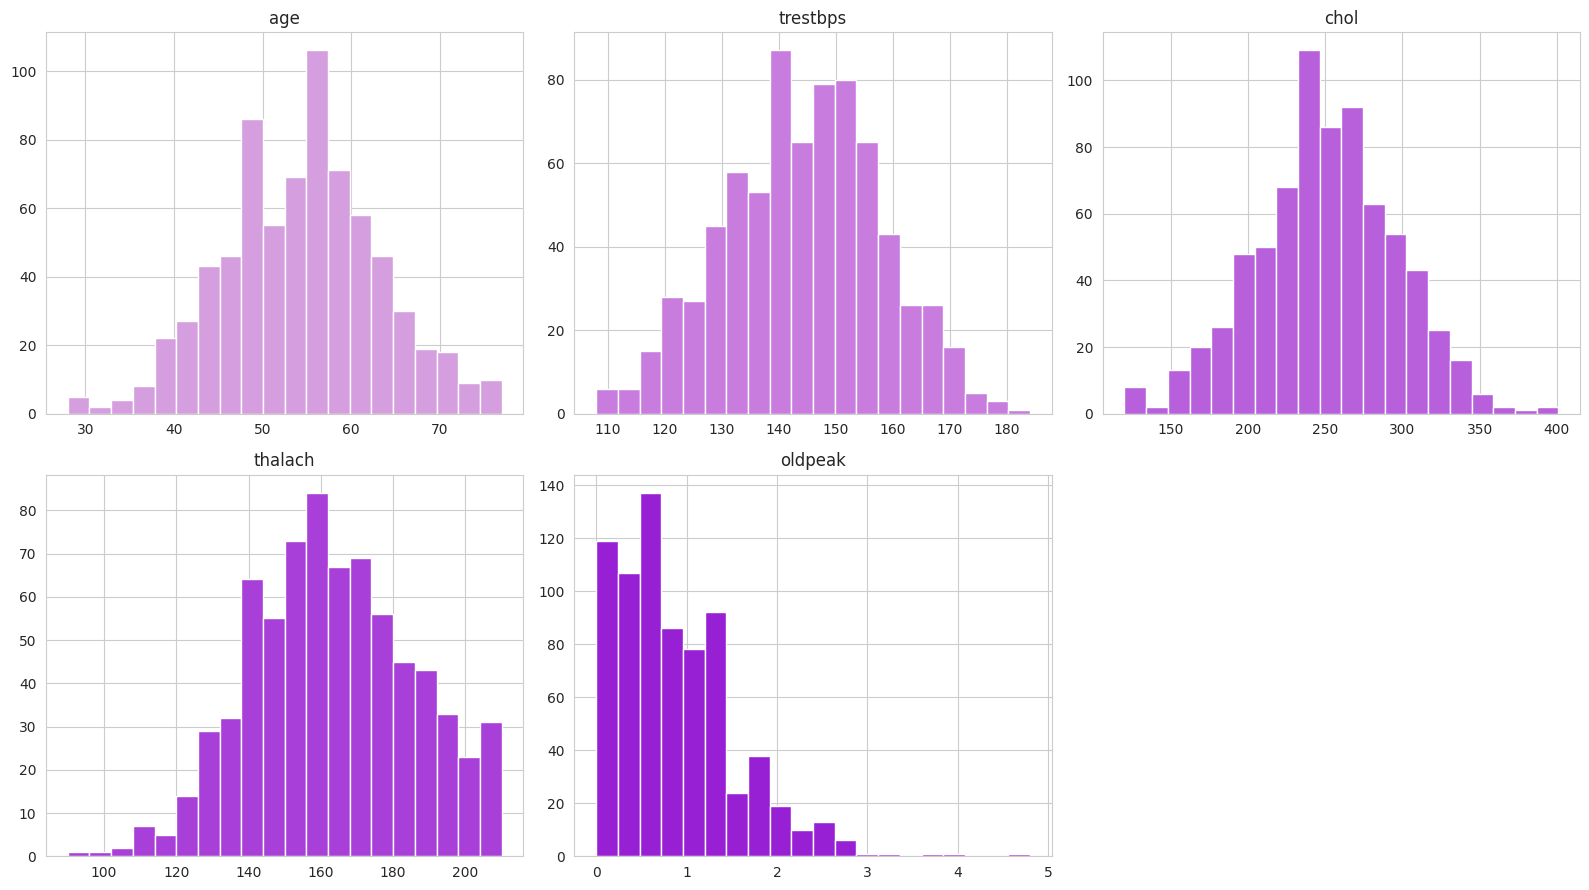

In [ ]:
df_num = train[["age", "trestbps", "chol", "thalach", "oldpeak"]]
df_cat = train[["target", "sex", "cp", "restecg", "slope", "thal"]]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
colors = ['#D59EDE', '#C87DDE', '#B85FDB', '#A83FD8', '#9820D4']
for i, col in enumerate(df_num.columns):
    axes[i].hist(df_num[col], color=colors[i], edgecolor='white', bins=20)
    axes[i].set_title(col)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### Heart disease prevalence by gender and chest pain type

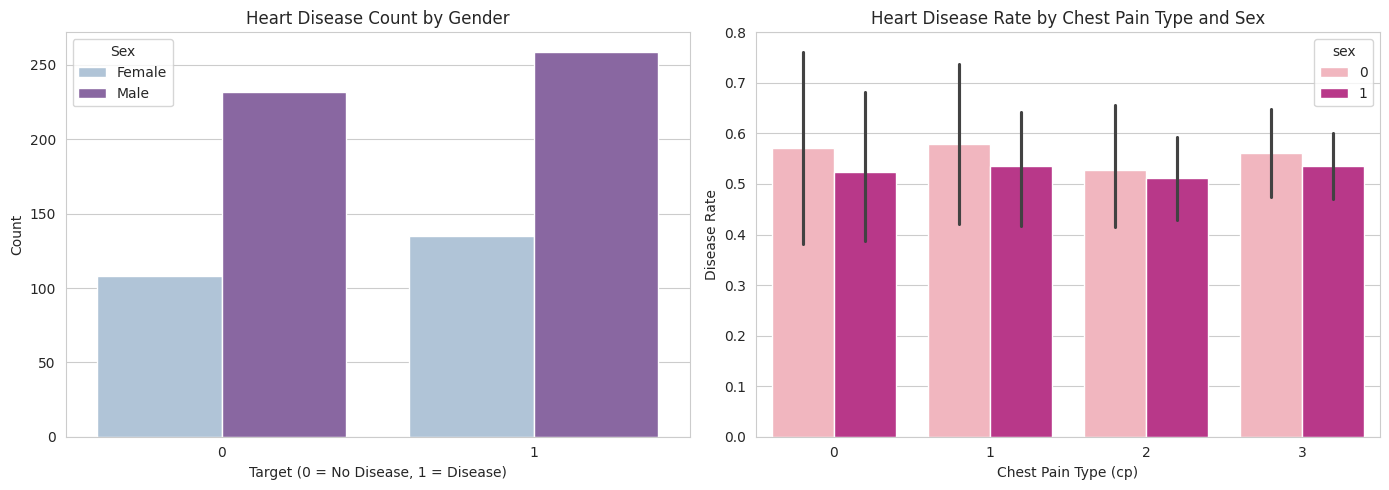

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(data=train, x='target', hue='sex', palette='BuPu')
plt.title('Heart Disease Count by Gender')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.legend(title='Sex', labels=['Female', 'Male'])

plt.subplot(1, 2, 2)
sns.barplot(data=train, x='cp', y='target', hue='sex', palette='RdPu')
plt.title('Heart Disease Rate by Chest Pain Type and Sex')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Disease Rate')

plt.tight_layout()
plt.show()

### Age and cholesterol distributions by target

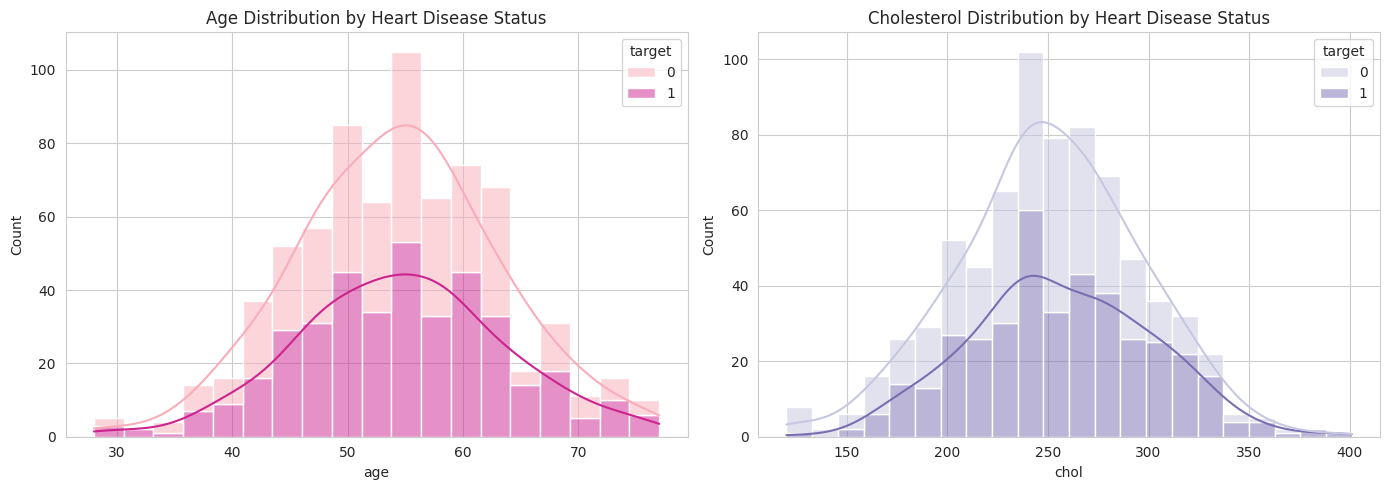

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=train, x='age', hue='target', kde=True, multiple='stack', palette='RdPu')
plt.title('Age Distribution by Heart Disease Status')

plt.subplot(1, 2, 2)
sns.histplot(data=train, x='chol', hue='target', kde=True, multiple='stack', palette='Purples')
plt.title('Cholesterol Distribution by Heart Disease Status')

plt.tight_layout()
plt.show()

### Target class balance

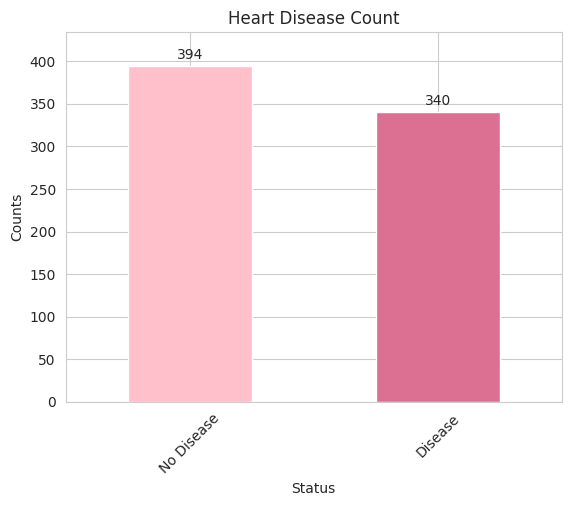

In [ ]:
target_count = train['target'].value_counts()

target_count.plot(kind='bar', color=['Pink', 'PaleVioletRed'])
plt.title('Heart Disease Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'], rotation=45)
plt.xlabel('Status')
plt.ylabel('Counts')
plt.ylim(0, max(target_count) + 40)

ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

### 🥧 Target proportion (pie chart)

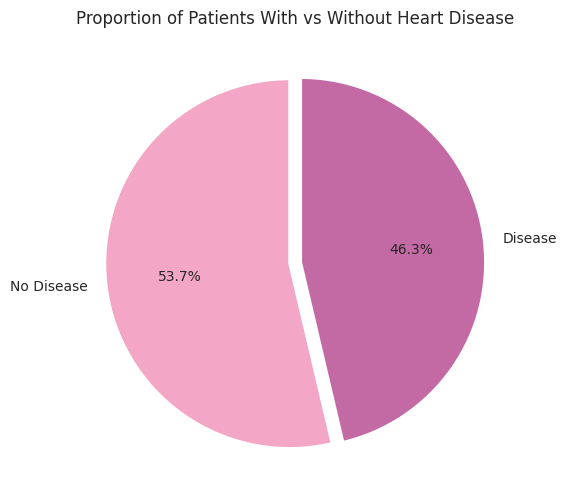

In [ ]:
plt.figure(figsize=(6, 6))
colors_pie = ['#F4A6C6', '#C36AA5']
explode = (0.03, 0.03)
plt.pie(target_count, labels=['No Disease', 'Disease'], autopct='%1.1f%%',
        colors=colors_pie, explode=explode, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Proportion of Patients With vs Without Heart Disease')
plt.show()

### Heart disease count by gender

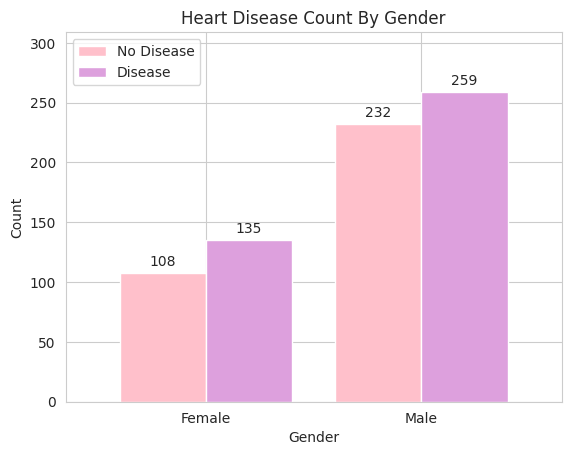

In [ ]:
gender_target = train.groupby(['sex', 'target']).size().unstack()

ax = gender_target.plot(kind='bar', color=['Pink', 'Plum'], width=0.8)
plt.title('Heart Disease Count By Gender')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'], rotation=0)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(labels=['No Disease', 'Disease'])
plt.ylim(0, gender_target.values.max() + 50)

for container in ax.containers:
    ax.bar_label(container, padding=3)
plt.show()

### Disease rate by chest pain type

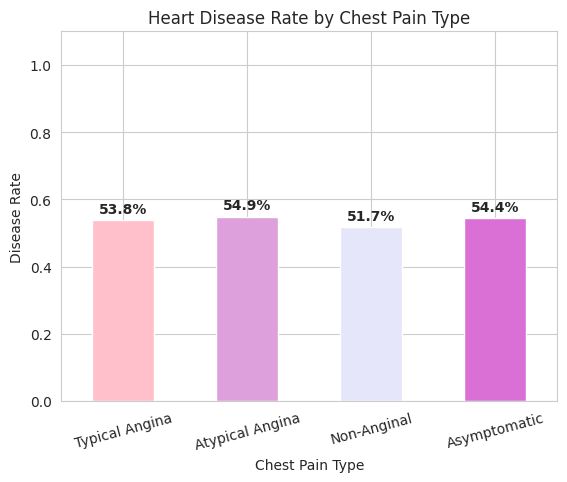

In [ ]:
cp_target = train.groupby('cp')['target'].mean()

ax = cp_target.plot(kind='bar', color=['Pink', 'Plum', 'Lavender', 'Orchid'])
plt.title('Heart Disease Rate by Chest Pain Type')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Typical Angina', 'Atypical Angina', 'Non-Anginal', 'Asymptomatic'], rotation=15)
plt.xlabel('Chest Pain Type')
plt.ylabel('Disease Rate')
plt.ylim(0, 1.1)

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt=lambda x: f'{x*100:.1f}%', fontweight='bold')
plt.show()

### Age distribution by disease status

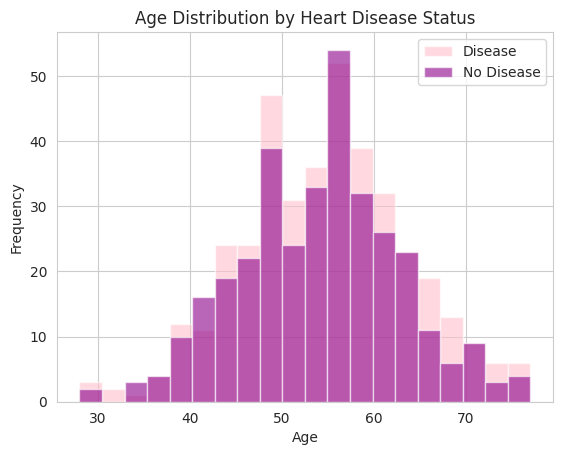

In [ ]:
age_data = train['age'].dropna()
bins = np.linspace(age_data.min(), age_data.max(), 21)

train[train['target']==1]['age'].plot(kind='hist', bins=bins, color='Pink', alpha=0.6, label='Disease', edgecolor='white')
train[train['target']==0]['age'].plot(kind='hist', bins=bins, color='DarkMagenta', alpha=0.6, label='No Disease', edgecolor='white')

plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### 🔥 Correlation heatmap

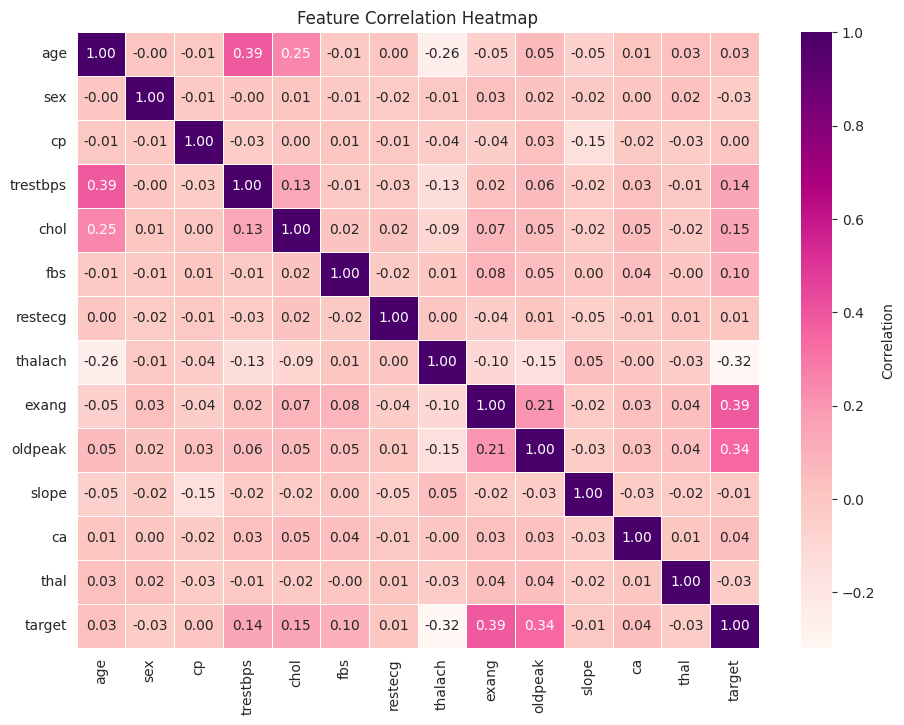

In [ ]:
plt.figure(figsize=(11, 8))
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Heatmap')
plt.show()

### 📦 Boxplots of key numeric features by target

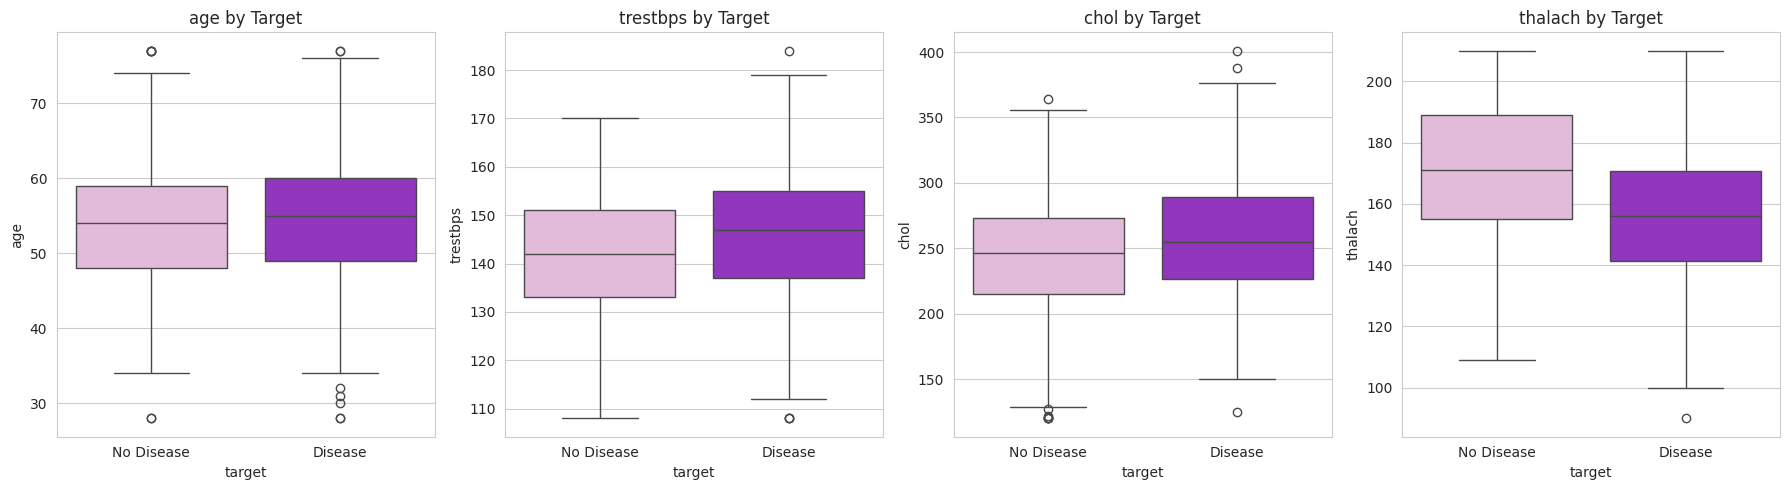

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
box_cols = ['age', 'trestbps', 'chol', 'thalach']
palette = {0: '#E8B4E0', 1: '#9820D4'}
for i, col in enumerate(box_cols):
    sns.boxplot(data=train, x='target', y=col, hue='target', palette=palette, ax=axes[i], legend=False)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Disease', 'Disease'])
    axes[i].set_title(f'{col} by Target')
plt.tight_layout()
plt.show()

### 🎻 Violin plot — max heart rate achieved vs target

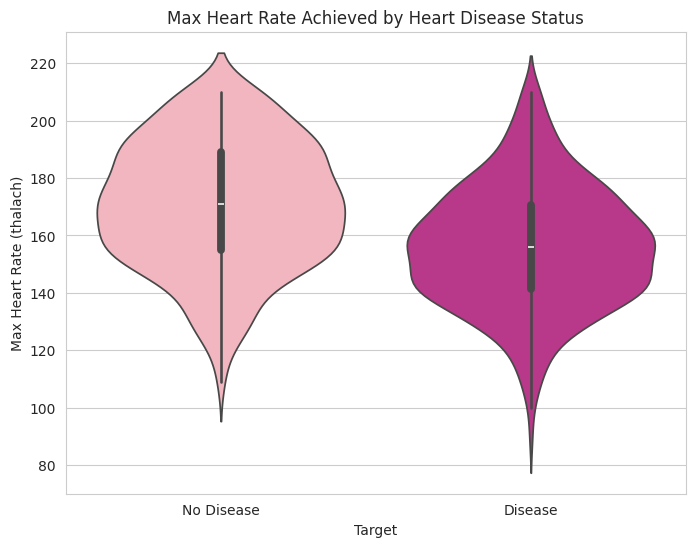

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=train, x='target', y='thalach', hue='target', palette='RdPu', legend=False)
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.title('Max Heart Rate Achieved by Heart Disease Status')
plt.xlabel('Target')
plt.ylabel('Max Heart Rate (thalach)')
plt.show()

### 🔗 Pairplot of key features

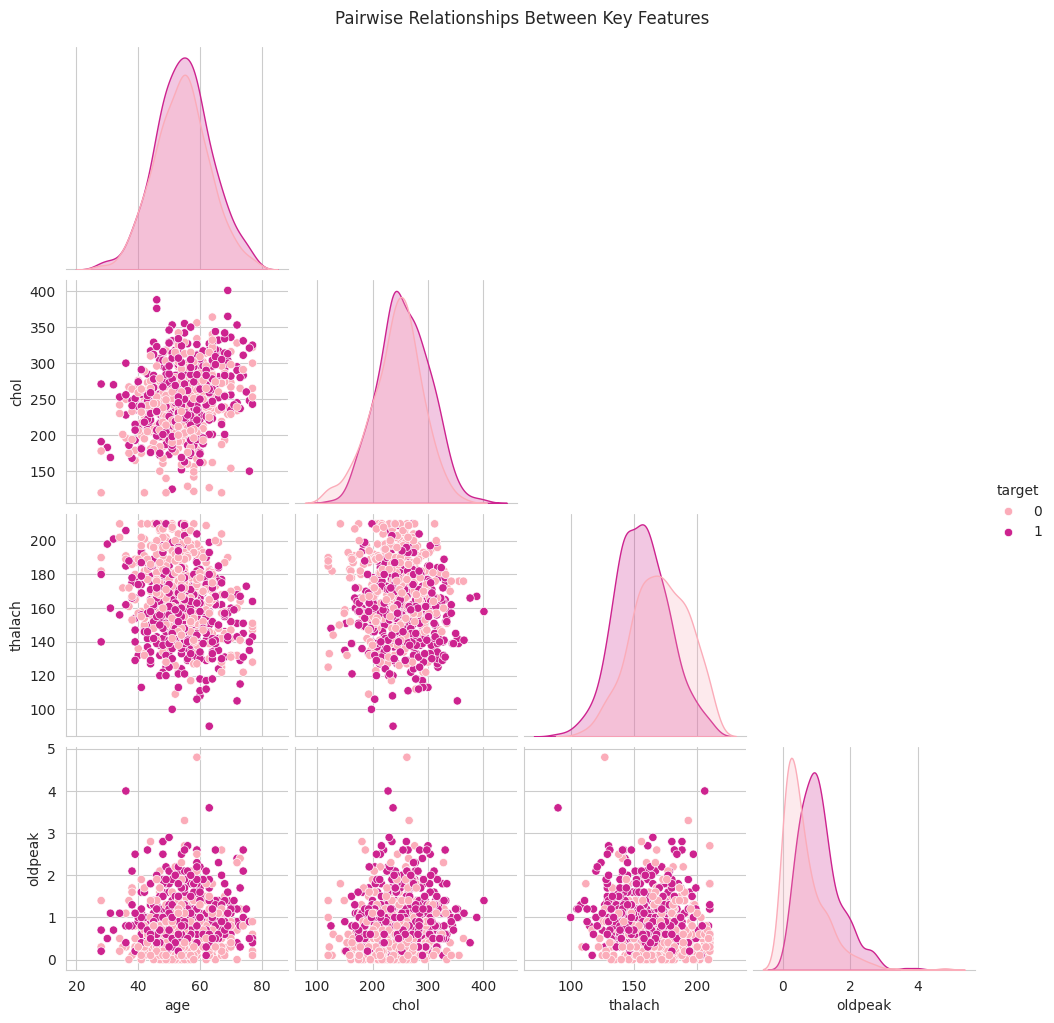

In [ ]:
sns.pairplot(train[['age', 'chol', 'thalach', 'oldpeak', 'target']],
             hue='target', palette='RdPu', diag_kind='kde', corner=True)
plt.suptitle('Pairwise Relationships Between Key Features', y=1.02)
plt.show()

## 4. Handling Missing Values

In [ ]:
# 1. Impute missing values for 'ca' (number of major vessels) with the median grouped by target
train['ca'] = train.groupby('target')['ca'].transform(lambda x: x.fillna(x.median()))
test['ca'] = test['ca'].fillna(train['ca'].median())

# 2. Impute missing values for 'thal' with the mode (most frequent category)
train['thal'] = train['thal'].fillna(train['thal'].mode()[0])
test['thal'] = test['thal'].fillna(train['thal'].mode()[0])

# Verify missing values are handled
print("Missing values in train after imputation:")
print(train.isnull().sum())
print("\nMissing values in test after imputation:")
print(test.isnull().sum())

Missing values in train after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values in test after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


## 5. Feature Engineering & Encoding

In [ ]:
# 1. Bin age into groups (can help linear models capture non-linear age effects)
train['AgeGroup'] = pd.cut(train['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)
test['AgeGroup'] = pd.cut(test['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)

# 2. One-hot encode multi-category features
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
train = pd.get_dummies(train, columns=categorical_cols, drop_first=True)
test = pd.get_dummies(test, columns=categorical_cols, drop_first=True)

# Align columns between train and test (in case of category mismatch)
train, test = train.align(test, join='left', axis=1, fill_value=0)
if 'target' in test.columns:
    test['target'] = test['target'].fillna(0).astype(int)

# 3. Feature Selection: separate features and target
train_target = train['target']
train_features = train.drop(columns=['target'])

test_target = test['target'] if 'target' in test.columns else None
test_features = test.drop(columns=['target']) if 'target' in test.columns else test.copy()

print("Features selected for training:")
print(train_features.head())

Features selected for training:
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak   ca  AgeGroup  \
0   56    0       140   237    0      142      1      0.9  0.0         2   
1   55    1       155   271    0      150      1      0.6  3.0         1   
2   39    0       120   235    0      154      0      1.1  1.0         0   
3   52    1       140   270    0      179      0      0.7  1.0         1   
4   62    1       159   235    0      141      1      0.5  0.0         2   

    cp_1   cp_2   cp_3  restecg_1  restecg_2  slope_1  slope_2  thal_2.0  \
0  False   True  False      False      False    False    False      True   
1  False   True  False      False       True     True    False     False   
2  False  False   True      False       True     True    False      True   
3  False   True  False      False      False     True    False     False   
4   True  False  False      False      False     True    False      True   

   thal_3.0  
0     False  
1      True  
2     False 

## 6. Model Comparison & Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost
import lightgbm
import pandas as pd
import numpy as np

# Define models
models = {
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVC': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42)),
    'KNN': make_pipeline(StandardScaler(), KNeighborsClassifier()),
    'XGBoost': xgboost.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': lightgbm.LGBMClassifier(random_state=42, verbosity=-1)
}

# Evaluate models using 5-Fold Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("--- 5-Fold Cross-Validation Accuracy ---")
for name, model in models.items():
    scores = cross_val_score(model, train_features, train_target, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}: Mean Accuracy = {scores.mean():.4f} (Std = {scores.std():.4f})")

# Perform GridSearch hyperparameter tuning on top candidates: Random Forest and Gradient Boosting
print("\n--- Hyperparameter Tuning ---")

# RF Tuning
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid=rf_param_grid, cv=cv, scoring='accuracy')
rf_grid.fit(train_features, train_target)
print(f"Best Random Forest CV Accuracy: {rf_grid.best_score_:.4f}")
print(f"Best parameters: {rf_grid.best_params_}")

# GB Tuning
gb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid=gb_param_grid, cv=cv, scoring='accuracy')
gb_grid.fit(train_features, train_target)
print(f"Best Gradient Boosting CV Accuracy: {gb_grid.best_score_:.4f}")
print(f"Best parameters: {gb_grid.best_params_}")

# Select best estimator
if rf_grid.best_score_ >= gb_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_name = "Random Forest (Tuned)"
    best_score = rf_grid.best_score_
else:
    best_model = gb_grid.best_estimator_
    best_name = "Gradient Boosting (Tuned)"
    best_score = gb_grid.best_score_

print(f"\nSelected Best Model: {best_name} with CV score {best_score:.4f}")

--- 5-Fold Cross-Validation Accuracy ---
Logistic Regression: Mean Accuracy = 0.7370 (Std = 0.0170)


Random Forest: Mean Accuracy = 0.7384 (Std = 0.0215)


Gradient Boosting: Mean Accuracy = 0.7302 (Std = 0.0284)


SVC: Mean Accuracy = 0.7125 (Std = 0.0305)
KNN: Mean Accuracy = 0.6703 (Std = 0.0407)


XGBoost: Mean Accuracy = 0.7030 (Std = 0.0326)
LightGBM: Mean Accuracy = 0.7248 (Std = 0.0328)

--- Hyperparameter Tuning ---


Best Random Forest CV Accuracy: 0.7589
Best parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}


Best Gradient Boosting CV Accuracy: 0.7602
Best parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

Selected Best Model: Gradient Boosting (Tuned) with CV score 0.7602


### 📊 Cross-validation accuracy comparison across models

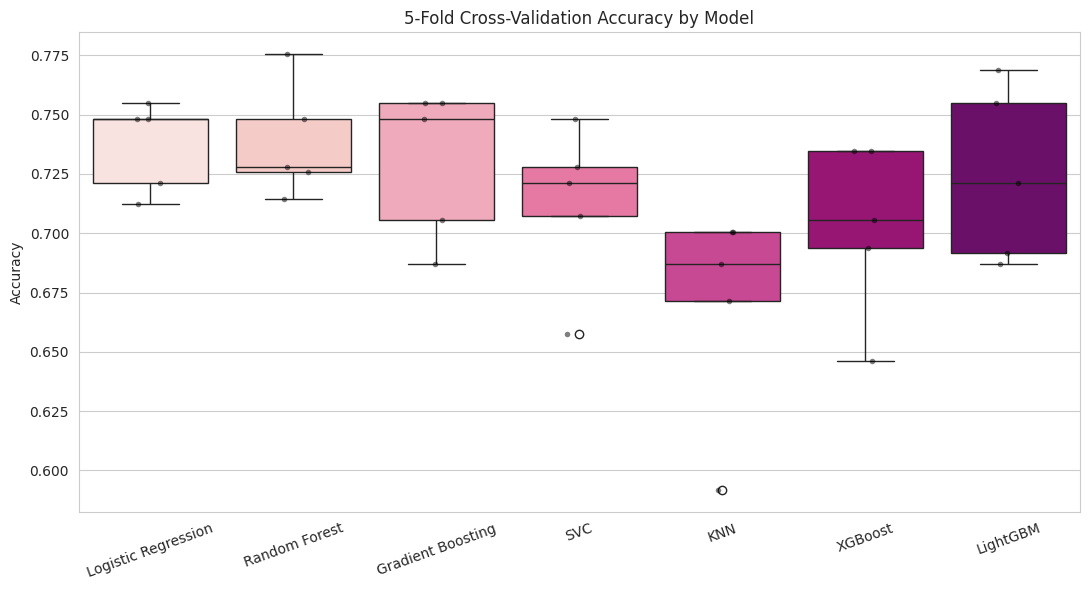

In [ ]:
cv_df = pd.DataFrame(cv_results)
plt.figure(figsize=(11, 6))
sns.boxplot(data=cv_df, palette='RdPu')
sns.stripplot(data=cv_df, color='black', alpha=0.5, size=4)
plt.title('5-Fold Cross-Validation Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 7. Final Evaluation on Test Set

In [ ]:
import os

# Train best model on full training dataset
best_model.fit(train_features, train_target)

# Predict on test set
predictions = best_model.predict(test_features)
probabilities = best_model.predict_proba(test_features)[:, 1] if hasattr(best_model, "predict_proba") else None

# Since our test.csv includes true labels, we can evaluate performance directly
if test_target is not None:
    acc = accuracy_score(test_target, predictions)
    print(f"Test Accuracy: {acc:.4f}\n")
    print("Classification Report:")
    print(classification_report(test_target, predictions, target_names=['No Disease', 'Disease']))

# Save predictions to csv
submission = pd.DataFrame({
    'PatientIndex': test_features.index,
    'Predicted_Target': predictions
})
submission_path = 'submissions/heart_predictions.csv'
os.makedirs(os.path.dirname(submission_path), exist_ok=True)
submission.to_csv(submission_path, index=False)
print(f"\nPredictions successfully saved to {submission_path}")
submission.head()

Test Accuracy: 0.7554

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.73      0.75      0.74        85
     Disease       0.78      0.76      0.77        99

    accuracy                           0.76       184
   macro avg       0.75      0.76      0.75       184
weighted avg       0.76      0.76      0.76       184


Predictions successfully saved to submissions/heart_predictions.csv


,PatientIndex,Predicted_Target
0,0,1
1,1,0
2,2,0
3,3,1
4,4,1


### 🎯 Confusion matrix

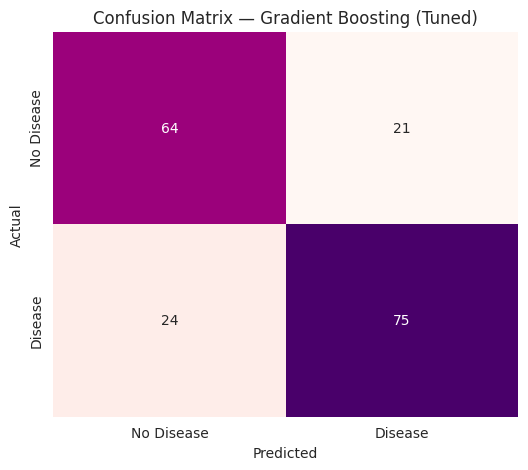

In [ ]:
cm = confusion_matrix(test_target, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', cbar=False,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 📈 ROC curve

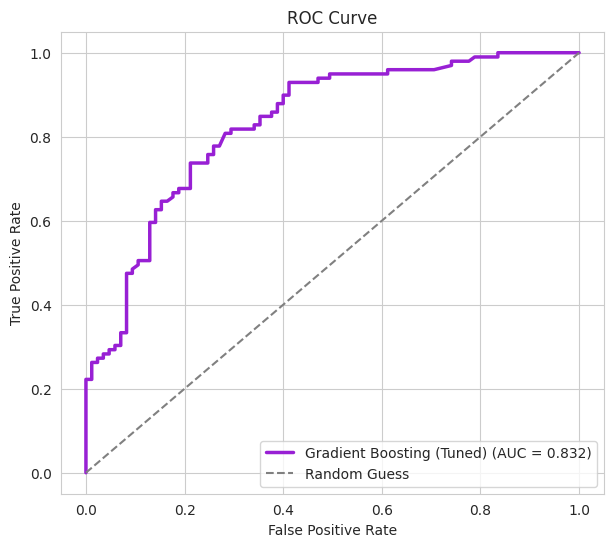

In [ ]:
if probabilities is not None:
    fpr, tpr, _ = roc_curve(test_target, probabilities)
    auc_score = roc_auc_score(test_target, probabilities)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='#9820D4', linewidth=2.5, label=f'{best_name} (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()

### 🌟 Feature importance

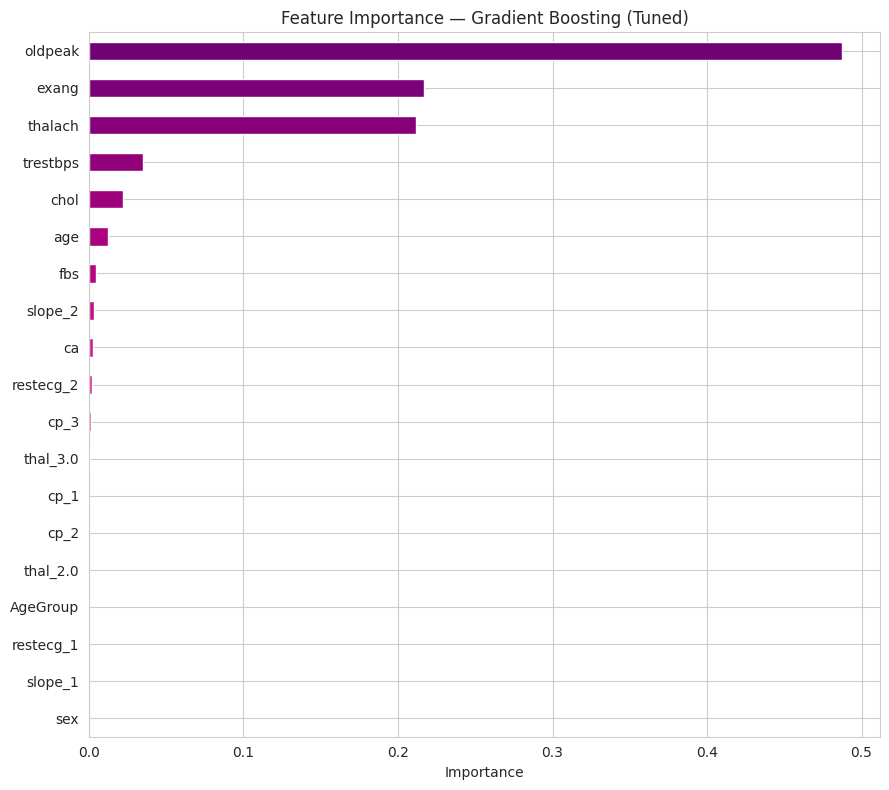

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=train_features.columns)
    importances = importances.sort_values(ascending=True)

    plt.figure(figsize=(9, 8))
    importances.plot(kind='barh', color=plt.cm.RdPu(np.linspace(0.4, 0.9, len(importances))))
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} does not expose feature_importances_ directly.")

## Summary

- Cleaned missing values in `ca` and `thal`
- Engineered `AgeGroup` and one-hot encoded categorical clinical features
- Compared 7 classifiers via 5-fold cross-validation
- Tuned Random Forest and Gradient Boosting with `GridSearchCV`
- Evaluated the best model on a held-out test set with accuracy, confusion matrix, ROC-AUC, and feature importance

Next steps: try SHAP values for deeper interpretability, or swap in the real UCI/Kaggle heart disease data for production-quality results.